In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/clean/db1b_agg.csv')
print(f"Loaded: {df.shape[0]:,} rows")
df.head()

Loaded: 176,405 rows


,Year,Quarter,Origin,Dest,OriginCityMarketID,DestCityMarketID,TkCarrier,Passengers,AvgFare,MedianFare,NonStopMiles,NumObs
0,2022,1,ABE,ATL,30135,30397,DL,446.0,208.256162,189.03,692.0,284
1,2022,1,ABE,BNA,30135,30693,G4,84.0,51.078431,47.00,685.0,51
2,2022,1,ABE,CLT,30135,31057,AA,206.0,233.775556,205.00,481.0,153
3,2022,1,ABE,DTW,30135,31295,DL,175.0,193.687910,160.00,425.0,134
4,2022,1,ABE,FLL,30135,32467,G4,329.0,81.002066,69.00,1041.0,121


In [3]:
import numpy as np
import pandas as pd

def cluster_robust_vcov(X, resid, cluster_ids, n_absorbed=0):
    """
    Cluster-robust (sandwich) covariance for OLS or within-FE OLS.
    X         : (N,k) regressors actually used in the final OLS. For FE models
                these are the WITHIN-transformed regressors (no FE dummies).
    resid     : (N,) residuals from that OLS.
    cluster_ids: (N,) cluster label per row (here: route).
    n_absorbed: number of FE parameters partialled out (for the dof correction).
    """
    X = np.asarray(X, float); resid = np.asarray(resid, float)
    N, k = X.shape
    bread = np.linalg.inv(X.T @ X)
    clusters = np.unique(cluster_ids)
    meat = np.zeros((k, k))
    for g in clusters:
        m = cluster_ids == g
        s = X[m].T @ resid[m]          # (k,)
        meat += np.outer(s, s)
    G = len(clusters)
    k_total = k + n_absorbed
    c = (G / (G - 1)) * ((N - 1) / (N - k_total))   # Stata-style small-sample adj.
    return c * (bread @ meat @ bread)

def demean(frame, value_cols, fe_cols, n_iter=100, tol=1e-12):
    """Iteratively demean value_cols by each FE dimension (within transform)."""
    work = frame[value_cols + fe_cols].copy().reset_index(drop=True)
    for _ in range(n_iter):
        maxch = 0.0
        for fe in fe_cols:
            for c in value_cols:
                gm = work.groupby(fe)[c].transform('mean')
                new = work[c] - gm
                maxch = max(maxch, float((new - work[c]).abs().max()))
                work[c] = new
        if maxch < tol:
            break
    return work[value_cols]

def run_fe(frame, value_cols, fe_cols, cluster_col='RouteID'):
    """OLS on within-demeaned data with cluster-robust SEs.
       value_cols[0] = dependent var; value_cols[1] = the DiD interaction."""
    dm = demean(frame, value_cols, fe_cols)
    y = dm[value_cols[0]].values
    X = dm[value_cols[1:]].values
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    n_abs = sum(frame[fe].nunique() for fe in fe_cols)
    V = cluster_robust_vcov(X, resid, frame[cluster_col].values, n_absorbed=n_abs)
    se = np.sqrt(np.diag(V)); t = beta / se
    return dict(names=value_cols[1:], beta=beta, se=se, t=t, n=len(y),
                n_routes=frame['RouteID'].nunique())

In [4]:
NK = 'NK'

# Routes Spirit served in 2022 vs 2025
r2022 = df[(df.TkCarrier==NK)&(df.Year==2022)][['Origin','Dest']].drop_duplicates()
r2025 = df[(df.TkCarrier==NK)&(df.Year==2025)][['Origin','Dest']].drop_duplicates()

# 176 exited routes (in 2022, not in 2025)
exited = r2022.merge(r2025, on=['Origin','Dest'], how='left', indicator=True)
exited = exited[exited._merge=='left_only'][['Origin','Dest']]
exited_set = set(map(tuple, exited.values))

# 86 "strong-exit" routes: Spirit avg >=500 pax/qtr in 2022, and exited
strong = (df[(df.TkCarrier==NK)&(df.Year==2022)]
            .groupby(['Origin','Dest']).Passengers.mean().reset_index())
strong = strong[strong.Passengers>=500][['Origin','Dest']]
strong = strong.merge(r2025, on=['Origin','Dest'], how='left', indicator=True)
strong = strong[strong._merge=='left_only'][['Origin','Dest']]
strong_set = set(map(tuple, strong.values))

ever_set = set(map(tuple, r2022.values))   # any Spirit presence in 2022

# Collapse non-Spirit carriers to the route-quarter level (passenger-weighted fare)
o = df[df.TkCarrier!=NK].copy()
o['FareXPax'] = o.AvgFare * o.Passengers
g = (o.groupby(['Year','Quarter','Origin','Dest'])
       .agg(FareXPax=('FareXPax','sum'), TotalPax=('Passengers','sum'),
            NumCarriers=('TkCarrier','nunique'), Distance=('NonStopMiles','first'))
       .reset_index())
g['WtdFare'] = g.FareXPax / g.TotalPax
g['LogFare'] = np.log(g.WtdFare)
g['LogPax']  = np.log(g.TotalPax + 1)
g['LogDist'] = np.log(g.Distance)
g['RouteID'] = g.Origin + '_' + g.Dest
g['rt']      = list(map(tuple, g[['Origin','Dest']].values))
g['SpiritExited'] = g.rt.isin(exited_set).astype(int)   # 176-route treatment
g['StrongExit']   = g.rt.isin(strong_set).astype(int)   # 86-route treatment
g['SpiritEver']   = g.rt.isin(ever_set).astype(int)
g['Control']      = (g.SpiritEver == 0).astype(int)
g['Post']   = ((g.Year>=2025)|((g.Year==2024)&(g.Quarter==4))).astype(int)
g['YQ_num'] = (g.Year-2022)*4 + g.Quarter
g['YQ']     = g.Year.astype(str)+'Q'+g.Quarter.astype(str)
g['Exit176_x_Post'] = g.SpiritExited * g.Post
g['Strong_x_Post']  = g.StrongExit  * g.Post

# Matched control: never-Spirit routes with >=2 carriers and distance 400-2000 mi
rs = (g.groupby('RouteID').agg(avg_carr=('NumCarriers','mean'),
                               dist=('Distance','first')).reset_index())
matched_routes = set(rs[(rs.avg_carr>=2)&(rs.dist>=400)&(rs.dist<=2000)].RouteID)
g['MatchedControl'] = ((g.Control==1)&(g.RouteID.isin(matched_routes))).astype(int)

df_reg = g
print(f"Route-quarter observations: {len(df_reg):,}")
print(f"Routes: {df_reg.RouteID.nunique():,} | Quarters: {df_reg.YQ.nunique()}")
print(f"Exited (176) flagged route-qtrs: {df_reg.SpiritExited.sum():,}")
print(f"Strong-exit (86) flagged route-qtrs: {df_reg.StrongExit.sum():,}")
print(f"Strong-exit routes: {len(strong_set)} | Exited routes: {len(exited_set)}")
print(f"Matched-control route-qtrs: {df_reg.MatchedControl.sum():,}")

Route-quarter observations: 112,794
Routes: 12,795 | Quarters: 14
Exited (176) flagged route-qtrs: 1,915
Strong-exit (86) flagged route-qtrs: 1,092
Strong-exit routes: 86 | Exited routes: 176
Matched-control route-qtrs: 14,856


In [5]:
m1 = df_reg
y  = m1.LogFare.values
X  = np.column_stack([np.ones(len(m1)), m1.SpiritExited, m1.Post,
                      m1.Exit176_x_Post, m1.LogDist, m1.LogPax])
names = ['Intercept','SpiritExited','Post','SpiritExited × Post','LogDist','LogPax']
beta  = np.linalg.lstsq(X, y, rcond=None)[0]
resid = y - X @ beta
V  = cluster_robust_vcov(X, resid, m1.RouteID.values, n_absorbed=0)
se = np.sqrt(np.diag(V)); t = beta / se

print("MODEL 1: OLS, 176-route treatment, cluster-robust SE (by route)")
print(f"{'Variable':<22}{'Coef':>10}{'ClustSE':>10}{'t':>8}")
for i,nm in enumerate(names):
    print(f"{nm:<22}{beta[i]:>10.4f}{se[i]:>10.4f}{t[i]:>8.2f}")
b, s = beta[3], se[3]
print(f"\nDiD coef {b:+.4f}  -> fare effect {(np.exp(b)-1)*100:+.1f}% "
      f"| 95% CI [{(np.exp(b-1.96*s)-1)*100:+.1f}%, {(np.exp(b+1.96*s)-1)*100:+.1f}%]")
m1_res = (b, s)

MODEL 1: OLS, 176-route treatment, cluster-robust SE (by route)
Variable                    Coef   ClustSE       t
Intercept                 3.8665    0.0435   88.82
SpiritExited             -0.0509    0.0214   -2.38
Post                      0.0283    0.0028   10.06
SpiritExited × Post      -0.0152    0.0136   -1.11
LogDist                   0.2190    0.0060   36.48
LogPax                    0.0037    0.0012    3.16

DiD coef -0.0152  -> fare effect -1.5% | 95% CI [-4.1%, +1.2%]


In [6]:
# M2: route FE only, 86-route treatment (Post stays in; not absorbed)
M2 = run_fe(df_reg, ['LogFare','Strong_x_Post','Post','LogPax'], ['RouteID'])

# M3 (= paper's "Model 2"): route + quarter FE, 86-route treatment
M3 = run_fe(df_reg, ['LogFare','Strong_x_Post','LogPax'], ['RouteID','YQ'])

# M4: route + quarter FE, 86-route treatment, MATCHED control only
m4_sample = df_reg[(df_reg.StrongExit==1) | (df_reg.MatchedControl==1)].copy()
M4 = run_fe(m4_sample, ['LogFare','Strong_x_Post','LogPax'], ['RouteID','YQ'])

def line(tag, res):
    b, s = res['beta'][0], res['se'][0]
    pct = (np.exp(b)-1)*100
    lo  = (np.exp(b-1.96*s)-1)*100
    hi  = (np.exp(b+1.96*s)-1)*100
    print(f"{tag:<34}{b:>9.4f}{s:>9.4f}{res['t'][0]:>7.2f}{pct:>8.1f}%"
          f"   [{lo:+.1f}%, {hi:+.1f}%]   N={res['n']:,}")

b1,s1 = m1_res
pct1=(np.exp(b1)-1)*100; lo1=(np.exp(b1-1.96*s1)-1)*100; hi1=(np.exp(b1+1.96*s1)-1)*100
print("Effect of Spirit exit on competitor fares (cluster-robust SE by route)")
print(f"{'Model':<34}{'Coef':>9}{'SE':>9}{'t':>7}{'%Δ':>8}   95% CI")
print("-"*88)
print(f"{'M1: OLS, 176 routes, no FE':<34}{b1:>9.4f}{s1:>9.4f}{b1/s1:>7.2f}"
      f"{pct1:>8.1f}%   [{lo1:+.1f}%, {hi1:+.1f}%]")
line('M2: Route FE, 86 routes', M2)
line('M3: Route+Qtr FE, 86 routes', M3)
line('M4: Route+Qtr FE, 86, matched ctrl', M4)

Effect of Spirit exit on competitor fares (cluster-robust SE by route)
Model                                  Coef       SE      t      %Δ   95% CI
----------------------------------------------------------------------------------------
M1: OLS, 176 routes, no FE          -0.0152   0.0136  -1.11    -1.5%   [-4.1%, +1.2%]
M2: Route FE, 86 routes              0.0131   0.0117   1.12     1.3%   [-1.0%, +3.7%]   N=112,794
M3: Route+Qtr FE, 86 routes          0.0129   0.0117   1.11     1.3%   [-1.0%, +3.6%]   N=112,794
M4: Route+Qtr FE, 86, matched ctrl   0.0063   0.0120   0.53     0.6%   [-1.7%, +3.0%]   N=15,948


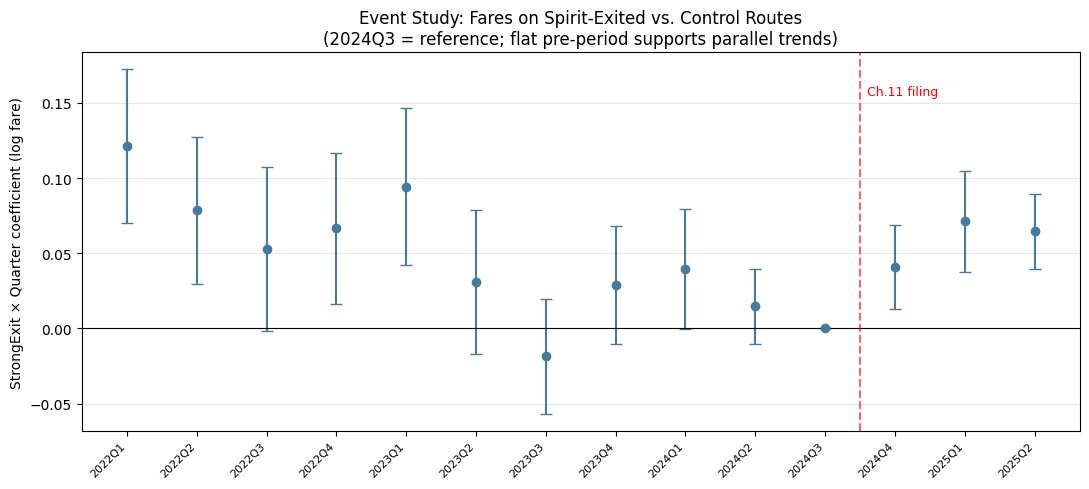

Pre-period (should be ~0 and individually insignificant if PT holds):
  2022Q1: +0.1211 (t=+4.63)  <-- significant pre-trend!
  2022Q2: +0.0785 (t=+3.15)  <-- significant pre-trend!
  2022Q3: +0.0528 (t=+1.90)
  2022Q4: +0.0665 (t=+2.59)  <-- significant pre-trend!
  2023Q1: +0.0942 (t=+3.54)  <-- significant pre-trend!
  2023Q2: +0.0306 (t=+1.25)
  2023Q3: -0.0186 (t=-0.96)
  2023Q4: +0.0289 (t=+1.44)
  2024Q1: +0.0394 (t=+1.94)
  2024Q2: +0.0148 (t=+1.17)


In [7]:
import matplotlib.pyplot as plt

REF = 11  # YQ_num for 2024Q3, the quarter just BEFORE the 2024Q4 filing
es = df_reg.copy()
es_cols, es_map = [], {}
for q in sorted(es.YQ_num.unique()):
    if q == REF:
        continue
    col = f'ES_{q}'
    es[col] = es.StrongExit * (es.YQ_num == q).astype(int)
    es_cols.append(col); es_map[col] = q

ES = run_fe(es, ['LogFare'] + es_cols + ['LogPax'], ['RouteID','YQ'])
coef = dict(zip(ES['names'], ES['beta']))
sek  = dict(zip(ES['names'], ES['se']))

# assemble for plotting (reference quarter pinned at 0)
xs = sorted(es.YQ_num.unique())
pts, los, his = [], [], []
for q in xs:
    if q == REF:
        pts.append(0); los.append(0); his.append(0)
    else:
        col = f'ES_{q}'
        b, s = coef[col], sek[col]
        pts.append(b); los.append(b-1.96*s); his.append(b+1.96*s)

labels = (es[['YQ_num','YQ']].drop_duplicates().sort_values('YQ_num').YQ.tolist())
fig, ax = plt.subplots(figsize=(11,5))
ax.errorbar(xs, pts, yerr=[np.array(pts)-np.array(los), np.array(his)-np.array(pts)],
            fmt='o', color='#457b9d', capsize=4, linewidth=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(11.5, color='red', ls='--', alpha=0.6)
ax.text(11.6, max(his)*0.9, 'Ch.11 filing', color='red', fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('StrongExit × Quarter coefficient (log fare)')
ax.set_title('Event Study: Fares on Spirit-Exited vs. Control Routes\n'
             '(2024Q3 = reference; flat pre-period supports parallel trends)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('figure_event_study.png', dpi=150); plt.show()

print("Pre-period (should be ~0 and individually insignificant if PT holds):")
for q in xs:
    if q < REF and q != REF:
        col=f'ES_{q}'; b,s=coef[col],sek[col]
        flag = '' if abs(b/s)<1.96 else '  <-- significant pre-trend!'
        print(f"  {labels[xs.index(q)]}: {b:+.4f} (t={b/s:+.2f}){flag}")

In [8]:
d = df[df.TkCarrier!='NK'].copy()
d['rt'] = list(map(tuple, d[['Origin','Dest']].values))
d['Period'] = np.where((d.Year>=2025)|((d.Year==2024)&(d.Quarter==4)),'Post','Pre')
d['grp'] = np.where(d.rt.isin(exited_set),'Exited',
            np.where(d.rt.isin(ever_set),'Stayed','Control'))

def pre_post(carrier, grp):
    sub = d[(d.TkCarrier==carrier)&(d.grp==grp)]
    pre  = sub[sub.Period=='Pre'].Passengers.mean()
    post = sub[sub.Period=='Post'].Passengers.mean()
    return pre, post

print("Carrier growth on EXITED routes vs. the same carrier on CONTROL routes")
print(f"{'Carr':<6}{'ExitedΔ%':>10}{'ControlΔ%':>11}{'DiD (pp)':>10}")
print("-"*40)
for c in ['DL','AA','WN','F9','B6']:
    ep, eo = pre_post(c,'Exited'); cp, co = pre_post(c,'Control')
    e_pct = (eo/ep-1)*100 if ep else np.nan
    c_pct = (co/cp-1)*100 if cp else np.nan
    print(f"{c:<6}{e_pct:>9.1f}%{c_pct:>10.1f}%{e_pct-c_pct:>9.1f}")

# Extensive-margin check you already had: non-Spirit carrier COUNT DiD
cc = (d.groupby(['Year','Quarter','rt','grp']).TkCarrier.nunique()
        .reset_index().rename(columns={'TkCarrier':'NumCarr'}))
cc['Period'] = np.where((cc.Year>=2025)|((cc.Year==2024)&(cc.Quarter==4)),'Post','Pre')
tab = cc[cc.grp.isin(['Exited','Control'])].groupby(['grp','Period']).NumCarr.mean().unstack()
did = (tab.loc['Exited','Post']-tab.loc['Exited','Pre']) - \
      (tab.loc['Control','Post']-tab.loc['Control','Pre'])
print(f"\nNon-Spirit carrier-count DiD: {did:+.3f}  "
      f"(near 0 => little NEW entry; backfill was intensive-margin)")
print(tab.round(2).to_string())

Carrier growth on EXITED routes vs. the same carrier on CONTROL routes
Carr    ExitedΔ%  ControlΔ%  DiD (pp)
----------------------------------------
DL         15.3%       3.1%     12.3
AA         16.3%       9.1%      7.2
WN         13.2%      31.2%    -17.9
F9          6.7%      -8.6%     15.2
B6          4.9%      38.7%    -33.8

Non-Spirit carrier-count DiD: -0.002  (near 0 => little NEW entry; backfill was intensive-margin)
Period   Post   Pre
grp                
Control  1.45  1.43
Exited   2.20  2.18


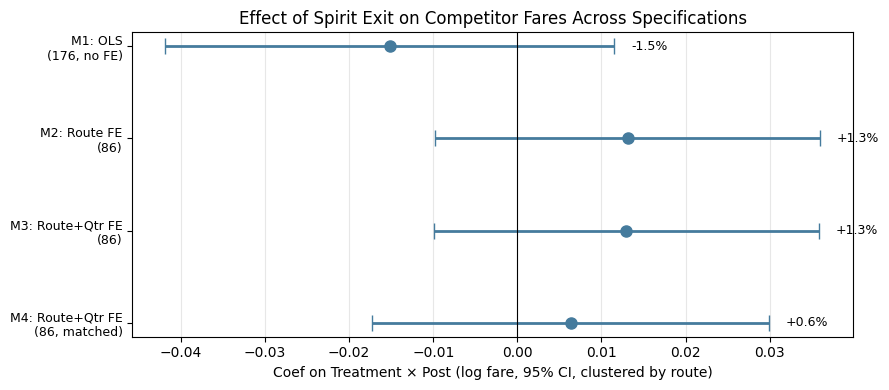

In [9]:
results = {
    'M1: OLS\n(176, no FE)':            m1_res,
    'M2: Route FE\n(86)':               (M2['beta'][0], M2['se'][0]),
    'M3: Route+Qtr FE\n(86)':           (M3['beta'][0], M3['se'][0]),
    'M4: Route+Qtr FE\n(86, matched)':  (M4['beta'][0], M4['se'][0]),
}
labels = list(results.keys())
coefs  = [v[0] for v in results.values()]
ses    = [v[1] for v in results.values()]

fig, ax = plt.subplots(figsize=(9,4))
yp = range(len(labels))
ax.errorbar(coefs, yp, xerr=[1.96*s for s in ses], fmt='o', color='#457b9d',
            markersize=8, capsize=6, linewidth=2)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(list(yp)); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Coef on Treatment × Post (log fare, 95% CI, clustered by route)')
ax.set_title('Effect of Spirit Exit on Competitor Fares Across Specifications')
for i,(c,s) in enumerate(zip(coefs,ses)):
    ax.text(c+1.96*s+0.002, i, f'{(np.exp(c)-1)*100:+.1f}%', va='center', fontsize=9)
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('figure3_coefficients.png', dpi=150); plt.show()

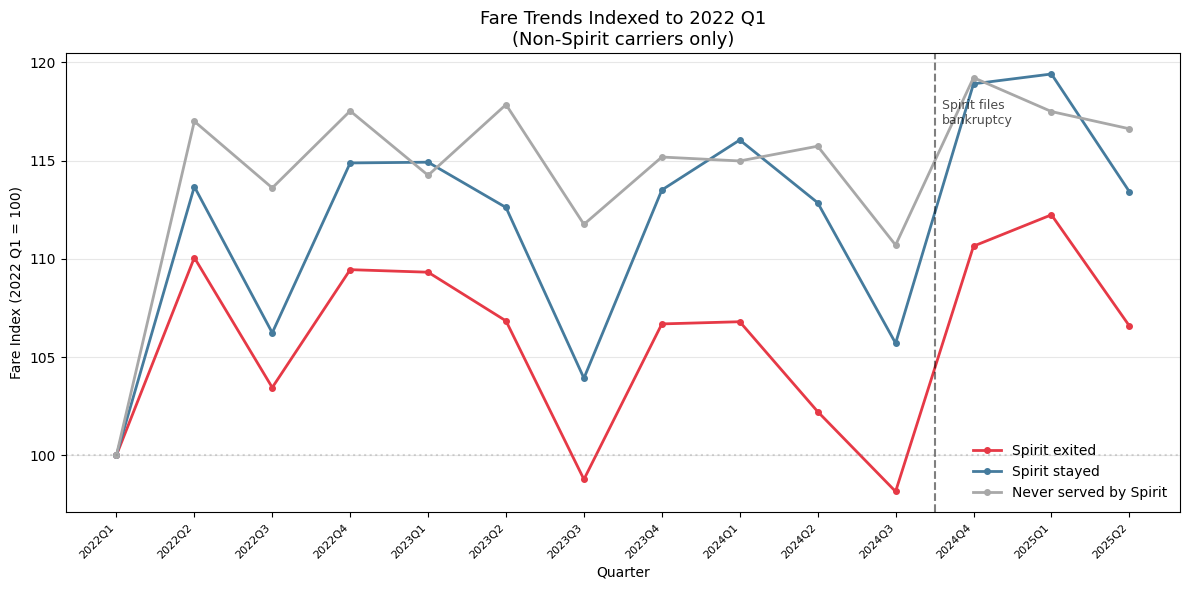


── Spirit exited ──
  2022Q1: 100.0
  2022Q2: 110.1
  2022Q3: 103.4
  2022Q4: 109.4
  2023Q1: 109.3
  2023Q2: 106.8
  2023Q3: 98.8
  2023Q4: 106.7
  2024Q1: 106.8
  2024Q2: 102.2
  2024Q3: 98.2
  2024Q4: 110.6
  2025Q1: 112.2
  2025Q2: 106.6

── Spirit stayed ──
  2022Q1: 100.0
  2022Q2: 113.7
  2022Q3: 106.2
  2022Q4: 114.9
  2023Q1: 114.9
  2023Q2: 112.6
  2023Q3: 103.9
  2023Q4: 113.5
  2024Q1: 116.0
  2024Q2: 112.9
  2024Q3: 105.7
  2024Q4: 118.9
  2025Q1: 119.4
  2025Q2: 113.4

── Never served by Spirit ──
  2022Q1: 100.0
  2022Q2: 117.0
  2022Q3: 113.6
  2022Q4: 117.5
  2023Q1: 114.3
  2023Q2: 117.9
  2023Q3: 111.8
  2023Q4: 115.2
  2024Q1: 115.0
  2024Q2: 115.7
  2024Q3: 110.7
  2024Q4: 119.2
  2025Q1: 117.5
  2025Q2: 116.6


In [10]:
# ── Figure 1: Fare Trends (Indexed to 2022 Q1) ──────────────────────────────
# Passenger-weighted average fare by group and quarter for non-Spirit carriers

df_viz = df[df.TkCarrier != 'NK'].copy()
df_viz['rt'] = list(map(tuple, df_viz[['Origin','Dest']].values))
df_viz['Group'] = np.where(df_viz.rt.isin(exited_set), 'Spirit exited',
                  np.where(df_viz.rt.isin(ever_set), 'Spirit stayed',
                           'Never served by Spirit'))
df_viz['YQ_num'] = (df_viz.Year - 2022) * 4 + df_viz.Quarter
df_viz['YQ'] = df_viz.Year.astype(str) + 'Q' + df_viz.Quarter.astype(str)

trends = (df_viz.groupby(['YQ_num','YQ','Group'])
          .apply(lambda g: pd.Series({
              'WtdAvgFare': (g.AvgFare * g.Passengers).sum() / g.Passengers.sum()
          })).reset_index())

colors = {'Spirit exited': '#e63946',
          'Spirit stayed': '#457b9d',
          'Never served by Spirit': '#a8a8a8'}

fig, ax = plt.subplots(figsize=(12, 6))
for group in ['Spirit exited', 'Spirit stayed', 'Never served by Spirit']:
    gdata = trends[trends.Group == group].sort_values('YQ_num').copy()
    base = gdata.WtdAvgFare.iloc[0]
    gdata['Indexed'] = (gdata.WtdAvgFare / base) * 100
    ax.plot(gdata.YQ_num, gdata.Indexed, marker='o', markersize=4,
            linewidth=2, color=colors[group], label=group)

ax.axvline(x=11.5, color='black', linestyle='--', alpha=0.5)
ax.text(11.6, ax.get_ylim()[1] * 0.97, 'Spirit files\nbankruptcy', fontsize=9, alpha=0.7)
ax.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Quarter')
ax.set_ylabel('Fare Index (2022 Q1 = 100)')
ax.set_title('Fare Trends Indexed to 2022 Q1\n(Non-Spirit carriers only)', fontsize=13)
xticks = trends[['YQ_num','YQ']].drop_duplicates().sort_values('YQ_num')
ax.set_xticks(xticks.YQ_num); ax.set_xticklabels(xticks.YQ, rotation=45, ha='right', fontsize=8)
ax.legend(frameon=False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('figure1_indexed_trends.png', dpi=150); plt.show()

# Print exact indexed values for reference
for group in ['Spirit exited', 'Spirit stayed', 'Never served by Spirit']:
    gdata = trends[trends.Group == group].sort_values('YQ_num').copy()
    base = gdata.WtdAvgFare.iloc[0]
    gdata['Indexed'] = (gdata.WtdAvgFare / base) * 100
    print(f"\n── {group} ──")
    for _, row in gdata.iterrows():
        print(f"  {row.YQ}: {row.Indexed:.1f}")

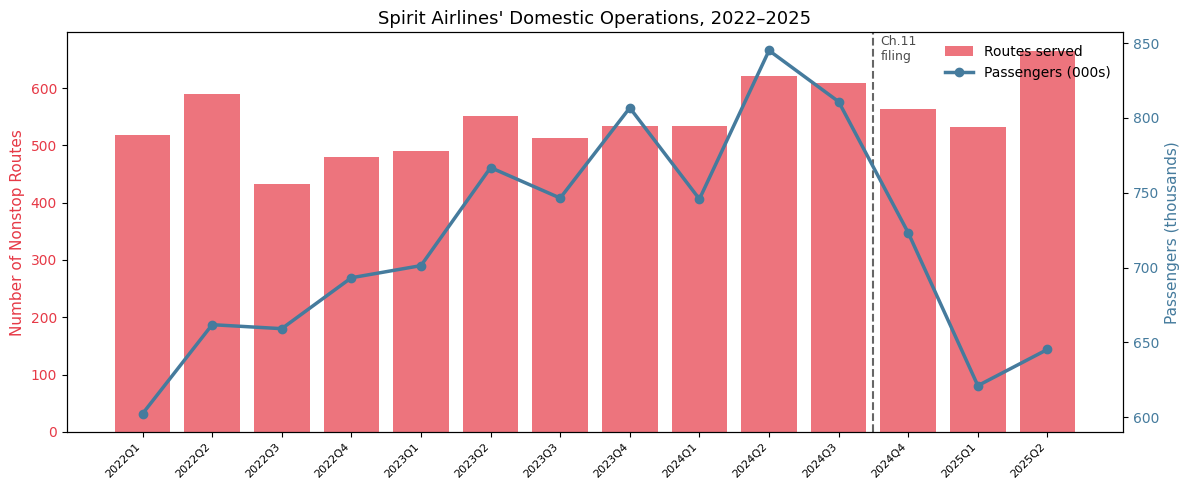


── Spirit Airlines by Quarter ──

Quarter      Routes   Passengers
--------------------------------
2022Q1          518      602,326
2022Q2          589      661,857
2022Q3          432      659,192
2022Q4          480      693,220
2023Q1          491      701,335
2023Q2          551      766,851
2023Q3          513      746,463
2023Q4          534      806,807
2024Q1          533      745,795
2024Q2          621      845,104
2024Q3          608      810,902
2024Q4          563      723,251
2025Q1          532      621,093
2025Q2          664      645,335


In [11]:
# ── Figure 3: Spirit Airlines' Domestic Operations ───────────────────────────

spirit_data = df[df.TkCarrier == 'NK'].copy()
spirit_data['YQ_num'] = (spirit_data.Year - 2022) * 4 + spirit_data.Quarter
spirit_data['YQ'] = spirit_data.Year.astype(str) + 'Q' + spirit_data.Quarter.astype(str)

spirit_quarterly = []
for (yq_num, yq), group in spirit_data.groupby(['YQ_num','YQ']):
    n_routes = group[['Origin','Dest']].drop_duplicates().shape[0]
    total_pax = group.Passengers.sum()
    spirit_quarterly.append({'YQ_num': yq_num, 'YQ': yq,
                             'NumRoutes': n_routes, 'TotalPax': total_pax})
spirit_qtr = pd.DataFrame(spirit_quarterly).sort_values('YQ_num')

fig, ax1 = plt.subplots(figsize=(12, 5))
color1, color2 = '#e63946', '#457b9d'

ax1.bar(spirit_qtr.YQ_num, spirit_qtr.NumRoutes, color=color1, alpha=0.7, label='Routes served')
ax1.set_ylabel('Number of Nonstop Routes', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(spirit_qtr.YQ_num, spirit_qtr.TotalPax / 1000,
         color=color2, marker='o', linewidth=2.5, label='Passengers (000s)')
ax2.set_ylabel('Passengers (thousands)', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=11.5, color='black', linestyle='--', alpha=0.6)
ax1.text(11.6, ax1.get_ylim()[1] * 0.93, 'Ch.11\nfiling', fontsize=9, alpha=0.7)
ax1.set_xticks(spirit_qtr.YQ_num.tolist())
ax1.set_xticklabels(spirit_qtr.YQ.tolist(), rotation=45, ha='right', fontsize=8)
ax1.set_title("Spirit Airlines' Domestic Operations, 2022–2025", fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)
plt.tight_layout(); plt.savefig('figure3_spirit_footprint.png', dpi=150); plt.show()

# Print quarterly summary table
print("\n── Spirit Airlines by Quarter ──\n")
print(f"{'Quarter':<10} {'Routes':>8} {'Passengers':>12}")
print("-" * 32)
for _, row in spirit_qtr.iterrows():
    print(f"{row.YQ:<10} {row.NumRoutes:>8} {row.TotalPax:>12,.0f}")

In [12]:
# ── Table 3: Carrier Backfill Detail ─────────────────────────────────────────
# Which specific carriers grew on Spirit-exited routes? (absolute numbers)

d_backfill = df[df.TkCarrier != 'NK'].copy()
d_backfill['rt'] = list(map(tuple, d_backfill[['Origin','Dest']].values))
d_backfill['Period'] = np.where(
    (d_backfill.Year >= 2025) | ((d_backfill.Year == 2024) & (d_backfill.Quarter == 4)),
    'Post', 'Pre')

df_exited_only = d_backfill[d_backfill.rt.isin(exited_set)]

carrier_growth = (
    df_exited_only
    .groupby(['TkCarrier','Period'])
    .agg(AvgQtrPax=('Passengers','mean'))
    .reset_index()
    .pivot(index='TkCarrier', columns='Period', values='AvgQtrPax')
    .fillna(0)
)
carrier_growth['Change'] = carrier_growth['Post'] - carrier_growth['Pre']
carrier_growth['PctChange'] = ((carrier_growth['Post'] / carrier_growth['Pre']) - 1) * 100
carrier_growth = carrier_growth.sort_values('Change', ascending=False)

print("── Which Carriers Grew on Spirit-Exited Routes? ──")
print("(Average quarterly passengers per route, pre vs post bankruptcy)\n")
print(f"{'Carrier':<10} {'Pre':>10} {'Post':>10} {'Change':>10} {'% Change':>10}")
print("-" * 55)
for carrier in carrier_growth.head(10).index:
    row = carrier_growth.loc[carrier]
    print(f"{carrier:<10} {row['Pre']:>10.0f} {row['Post']:>10.0f} "
          f"{row['Change']:>+10.0f} {row['PctChange']:>+9.1f}%")
print(f"\n{'TOTAL':<10} {carrier_growth['Pre'].sum():>10.0f} "
      f"{carrier_growth['Post'].sum():>10.0f} {carrier_growth['Change'].sum():>+10.0f}")

── Which Carriers Grew on Spirit-Exited Routes? ──
(Average quarterly passengers per route, pre vs post bankruptcy)

Carrier           Pre       Post     Change   % Change
-------------------------------------------------------
DL               2455       2832       +377     +15.3%
AA               1067       1240       +174     +16.3%
WN               1119       1268       +148     +13.2%
F9               1353       1443        +90      +6.7%
B6               1410       1479        +69      +4.9%
SY               1946       1992        +46      +2.3%
MX                330        371        +41     +12.5%
G4                117        122         +5      +4.6%
AC                  1          2         +1    +100.0%
PR                  1          1         +0      +0.0%

TOTAL           12283      12937       +654
